In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [3]:
# ---------------------------
# 1) Preparing the data
# ---------------------------

X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)     # labels 0/1

# seperate train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [4]:
# ---------------------------
# 2) Fuzzy C-Means for Initialization
# ---------------------------

def fcm_initialize(X, K, m=2.0):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs)
    """
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)   # (N,1)
        diff = X - cntr[k]             # (N, n_inputs)
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff ** 2), axis=0) / denom
        spreads.append(np.sqrt(var))
    spreads = np.array(spreads)
    spreads = np.clip(spreads, 1e-3, None)
    return np.array(cntr), spreads


In [5]:
# ---------------------------
# 3) Gaussian + Sigmoid MF (with alpha_beta)
# ---------------------------

class GaussianSigmoidMF(nn.Module):
    def __init__(self, centers_init, spreads_init, s_mode="C", eps_s=1e-6):
        """
        centers_init: (K, n_inputs)
        spreads_init: (K, n_inputs)
        s_mode: "C" or "alpha_beta"
           - "C": learn C_j^i and s = sigmoid(C)
           - "alpha_beta": learn alpha and beta and s = alpha^2 / (alpha^2 + beta^2 + eps)
        eps_s: small value to avoid division by zero
        """
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]
        self.eps_s = eps_s
        self.s_mode = s_mode

        # m_j^i: centers
        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))  # (K, n_inputs)

        # sigma_j^i: spreads - store as raw parameter but use softplus to ensure positivity
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))  # (K, n_inputs)

        if s_mode == "C":
            # learn C per (K, n_inputs)
            # initialize to 0 so s = 0.5 initially
            self.C = nn.Parameter(torch.zeros(self.K, self.n_inputs, dtype=torch.float32))
        elif s_mode == "alpha_beta":
            # learn alpha and beta; initialize alpha ~ 1, beta ~ 1 -> s ~ 0.5
            self.alpha = nn.Parameter(torch.ones(self.K, self.n_inputs, dtype=torch.float32))
            self.beta  = nn.Parameter(torch.ones(self.K, self.n_inputs, dtype=torch.float32))
        else:
            raise ValueError("s_mode must be 'C' or 'alpha_beta'")

    def forward(self, x):
        """
        x: (batch, n_inputs)
        returns firing strengths: (batch, K) derived from product of blended MFs across inputs
        """
        batch = x.shape[0]

        # expand for broadcasting
        x_exp = x.unsqueeze(1)  # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)  # (1, K, n_inputs)
        # positive spreads via softplus
        s_raw = torch.nn.functional.softplus(self.spreads).unsqueeze(0)  # (1, K, n_inputs)
        s_raw = torch.clamp(s_raw, min=1e-6)

        # Gaussian MF: exp(-((x-c)^2) / (2 * sigma^2))
        mu_gauss = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (s_raw ** 2) + 1e-12))  # (batch, K, n_inputs)

        # Sigmoid-like MF: sigmoid( - (1/sigma) * (x - m) )
        mu_sigexponent = - (1.0 / (s_raw + 1e-12)) * (x_exp - c_exp)  # (batch, K, n_inputs)
        mu_sig = torch.sigmoid(mu_sigexponent)  # (batch, K, n_inputs)

        # compute s_j^i mixing factor
        if self.s_mode == "C":
            # s = sigmoid(C)
            C_exp = self.C.unsqueeze(0)  # (1, K, n_inputs)
            s_mix = torch.sigmoid(C_exp)  # (1, K, n_inputs) in (0,1)
        else:  # alpha_beta
            alpha_exp = self.alpha.unsqueeze(0)
            beta_exp  = self.beta.unsqueeze(0)
            # s_j^i = alpha^2 / (alpha^2 + beta^2 + eps)
            s_mix = alpha_exp ** 2 / (alpha_exp ** 2 + beta_exp ** 2 + self.eps_s)
            s_mix = torch.clamp(s_mix, min=0.0, max=1.0)

        # Broadcast s_mix to (batch, K, n_inputs)
        s_mix_b = s_mix.expand(batch, -1, -1)

        # blended MF
        mu_plus = s_mix_b * mu_gauss + (1.0 - s_mix_b) * mu_sig  # (batch, K, n_inputs)

        # combine across inputs using product (AND)
        firing = torch.prod(mu_plus, dim=2)  # (batch, K)
        return firing

In [6]:
# ---------------------------
# 4) ANFIS Model With New MF
# ---------------------------

class ANFIS_BlendMF(nn.Module):
    def __init__(self, centers_init, spreads_init, s_mode="C"):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        # fuzzy layer (unchanged)
        self.mf_layer = GaussianSigmoidMF(centers_init, spreads_init, s_mode=s_mode)

        # ---- Classification consequents ----
        # Each rule outputs ONE logit (scalar)
        # No linear dependence on x
        self.consequents = nn.Parameter(torch.randn(self.K, 1) * 0.1)

    def forward(self, x):
        # x: (batch, n_inputs)

        # Firing strengths from fuzzy layer
        w = self.mf_layer(x)  # (batch, K)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum     # (batch, K)

        # rule logits (shape: 1 × K)
        y_r = self.consequents.view(1, self.K)  # (1, K)

        # Weighted sum → final logit (batch × 1)
        logit = torch.sum(w_norm * y_r, dim=1, keepdim=True)

        # FINAL PROBABILITY FOR CLASS 1
        prob = torch.sigmoid(logit)

        return prob

In [7]:
# ---------------------------
# 5) Training (Classification)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels to float for BCE
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.from_numpy(X_train).to(device)
X_test_tensor  = torch.from_numpy(X_test).to(device)

# initialization
K = 6  
centers_init, spreads_init = fcm_initialize(X_train, K)

# Model setup
s_mode_choice = "alpha_beta"   # or "C"
model = ANFIS_BlendMF(centers_init, spreads_init, s_mode=s_mode_choice).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Loss (still BCE because model outputs probabilities)
loss_fn = nn.BCELoss()

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward
    y_pred_train = model(X_train_tensor)

    # Loss
    loss = loss_fn(y_pred_train, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Progress logging
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = model(X_train_tensor)
            test_prob  = model(X_test_tensor)

            # RMSE calculation
            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor)**2)).item()
            test_rmse  = torch.sqrt(torch.mean((test_prob  - y_test_tensor )**2)).item()

        print(f"Epoch {epoch}/{n_epochs}  Loss: {loss.item():.4f}  "
              f"Train RMSE: {train_rmse:.4f}  Test RMSE: {test_rmse:.4f}")

# Restore best parameters
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()


# ---------------------------
# 6) Final Evaluation
# ---------------------------
with torch.no_grad():
    final_train_prob = model(X_train_tensor).cpu().numpy().reshape(-1)
    final_test_prob  = model(X_test_tensor).cpu().numpy().reshape(-1)

# Final RMSE
train_rmse = np.sqrt(np.mean((final_train_prob - y_train)**2))
test_rmse  = np.sqrt(np.mean((final_test_prob  - y_test )**2))

print("\nFinal Results:")
print("Mode:", s_mode_choice)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")


/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 1/1000  Loss: 0.6954  Train RMSE: 0.5011  Test RMSE: 0.5012
Epoch 100/1000  Loss: 0.6813  Train RMSE: 0.4940  Test RMSE: 0.4943
Epoch 200/1000  Loss: 0.6590  Train RMSE: 0.4825  Test RMSE: 0.4832
Epoch 300/1000  Loss: 0.6217  Train RMSE: 0.4629  Test RMSE: 0.4637
Epoch 400/1000  Loss: 0.5760  Train RMSE: 0.4381  Test RMSE: 0.4383
Epoch 500/1000  Loss: 0.5307  Train RMSE: 0.4128  Test RMSE: 0.4121
Epoch 600/1000  Loss: 0.4883  Train RMSE: 0.3888  Test RMSE: 0.3869
Epoch 700/1000  Loss: 0.4513  Train RMSE: 0.3677  Test RMSE: 0.3648
Epoch 800/1000  Loss: 0.4200  Train RMSE: 0.3502  Test RMSE: 0.3467
Epoch 900/1000  Loss: 0.3971  Train RMSE: 0.3376  Test RMSE: 0.3340
Epoch 1000/1000  Loss: 0.3794  Train RMSE: 0.3275  Test RMSE: 0.3247

Final Results:
Mode: alpha_beta
Train RMSE: 0.3275
Test RMSE : 0.3247


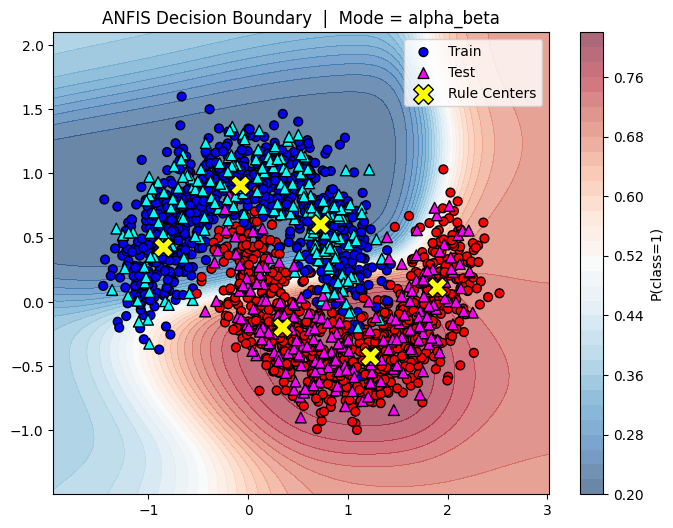

In [8]:
    # ---------------------------
    # 7: Plot decision boundary
    # ---------------------------
    plt.figure(figsize=(8, 6))
    
    # Grid for visualization
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = torch.from_numpy(grid).to(device)
    
    with torch.no_grad():
        prob_grid = model(grid_tensor).cpu().numpy().reshape(xx.shape)
    
    # Decision boundary contour
    contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
    plt.colorbar(contour, label="P(class=1)")
    
    # Training data
    plt.scatter(
        X_train[:, 0], X_train[:, 1], 
        c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
    )
    
    # Test data
    plt.scatter(
        X_test[:, 0], X_test[:, 1], 
        c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
    )
    
    # Optional: show rule centers
    plt.scatter(
        centers_init[:, 0], centers_init[:, 1],
        c="yellow", s=200, edgecolor="black", marker="X",
        label="Rule Centers"
    )
    
    plt.title(f"ANFIS Decision Boundary  |  Mode = {s_mode_choice}")
    plt.legend()
    plt.show()
